In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [ ]:
contacts=load("../complex/complexContacts_1d_trajectory1.npy")
plot(sum(contact,axis = 1))

(501, 9506980)

(0.0, 205.0)

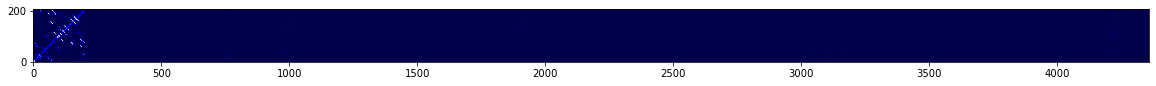

In [5]:
figure(figsize = (20,100))
imshow(contacts_2d,origin = "lower",cmap = "seismic")
ylim(0,205)

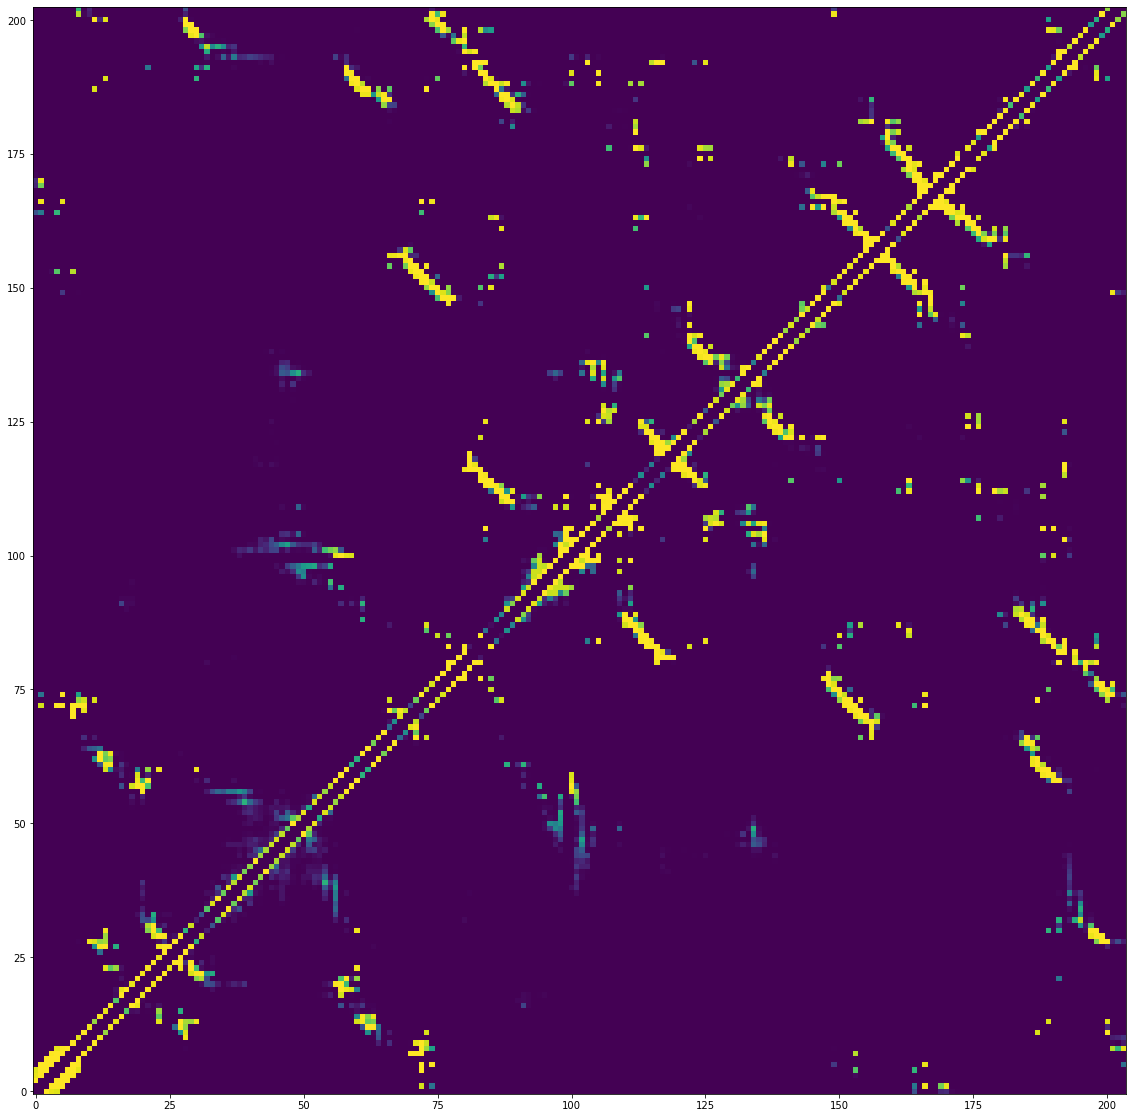

In [6]:
figure(figsize = (20,20))
imshow(contacts_2d[:493-290,:493-290+1],origin = "lower")

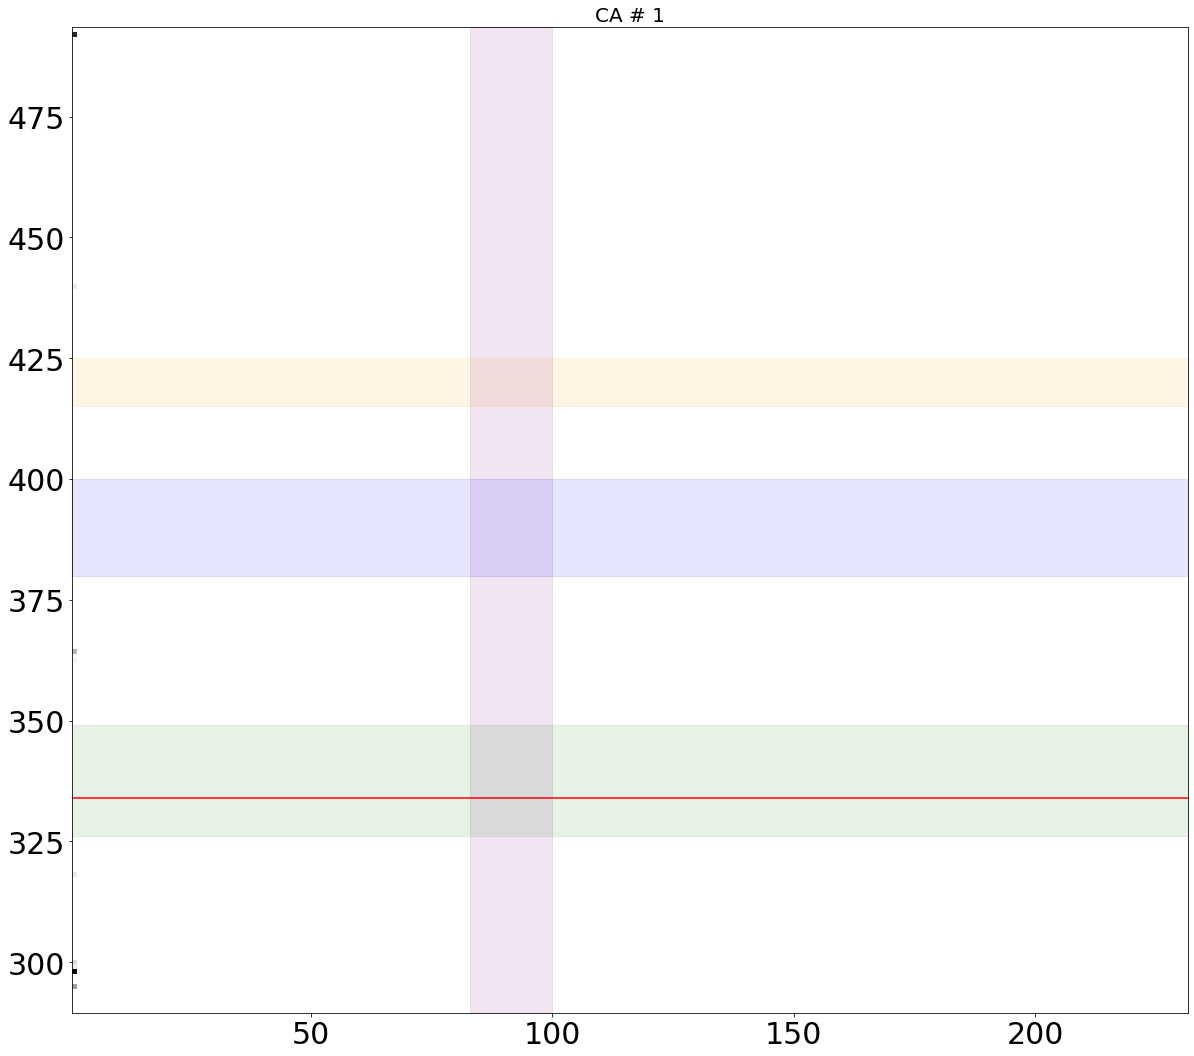

In [7]:
i=1
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


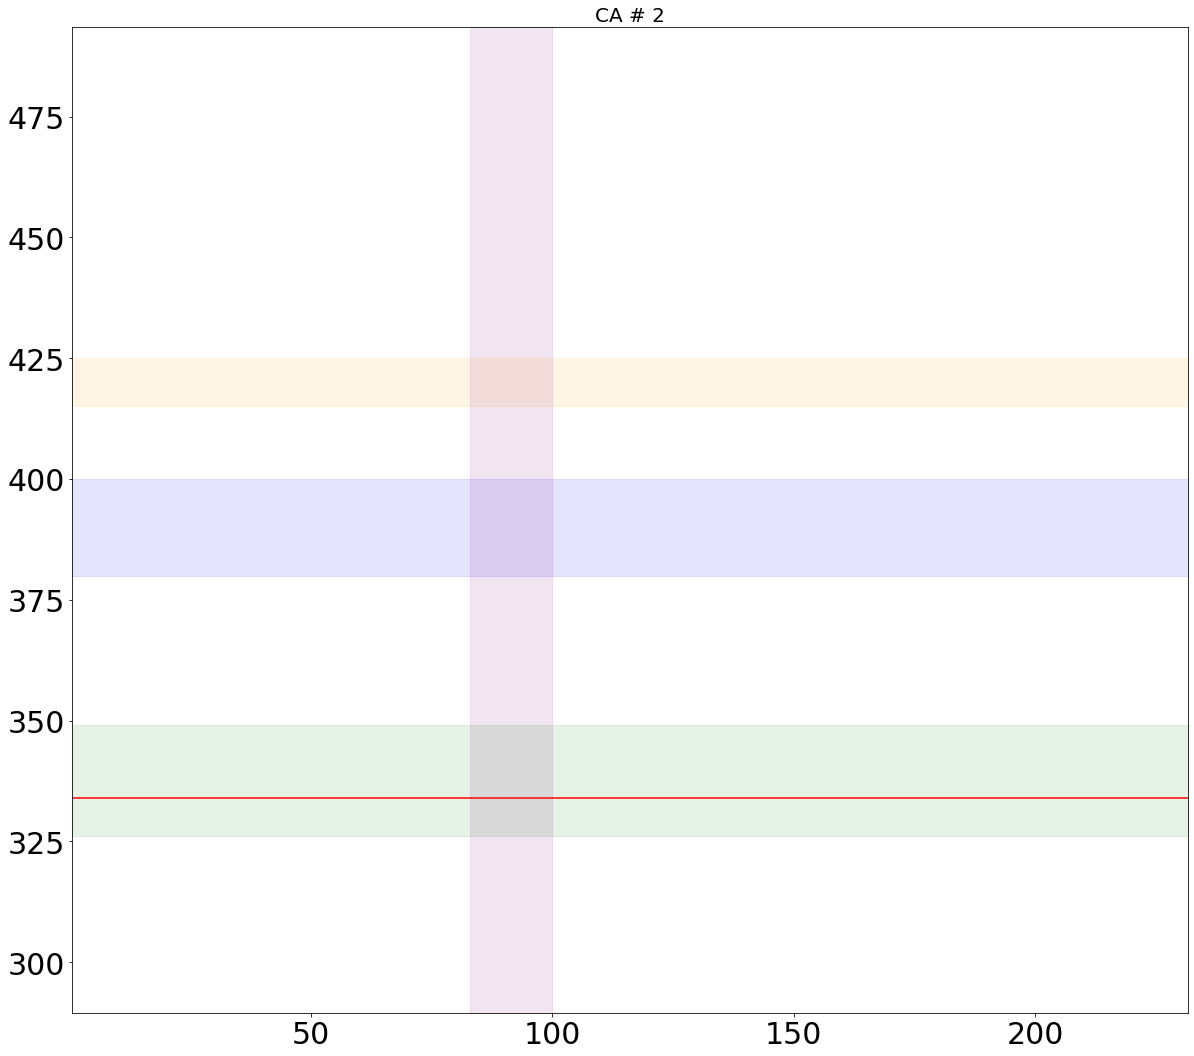

In [28]:
i=2
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)
#colorbar()
xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


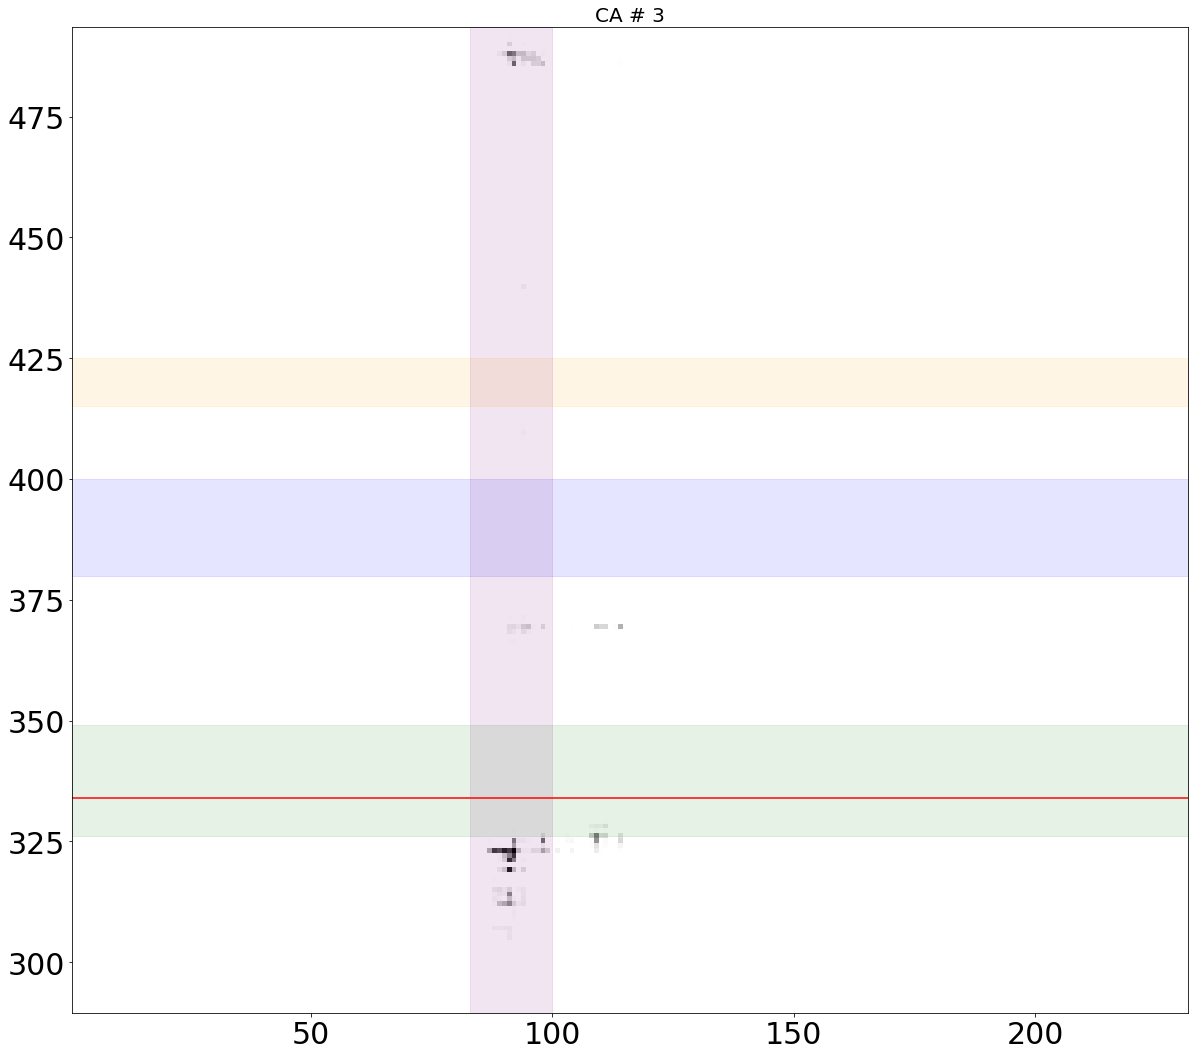

In [27]:
i=3
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


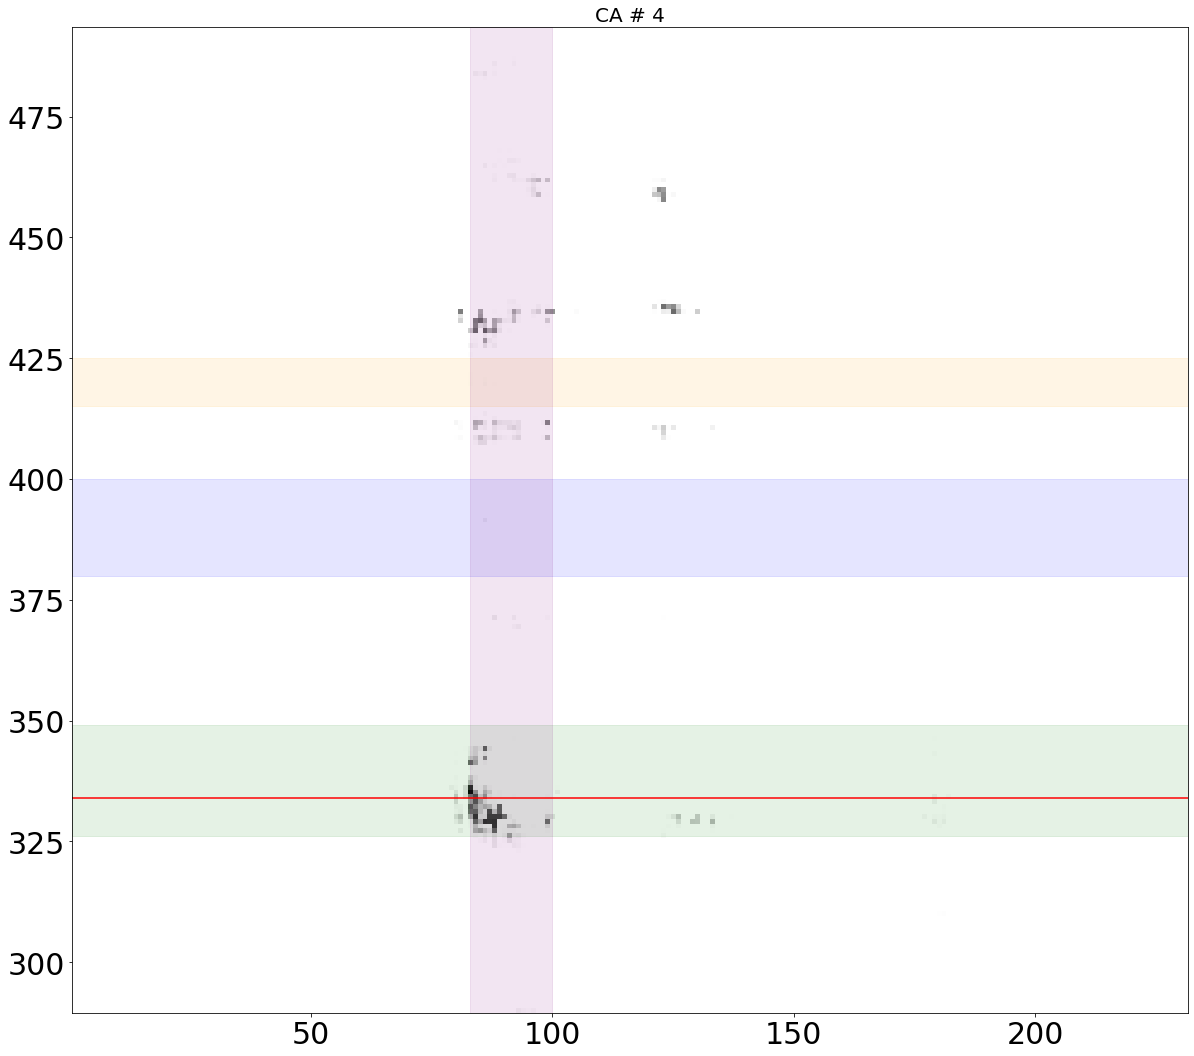

In [10]:
i=4
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


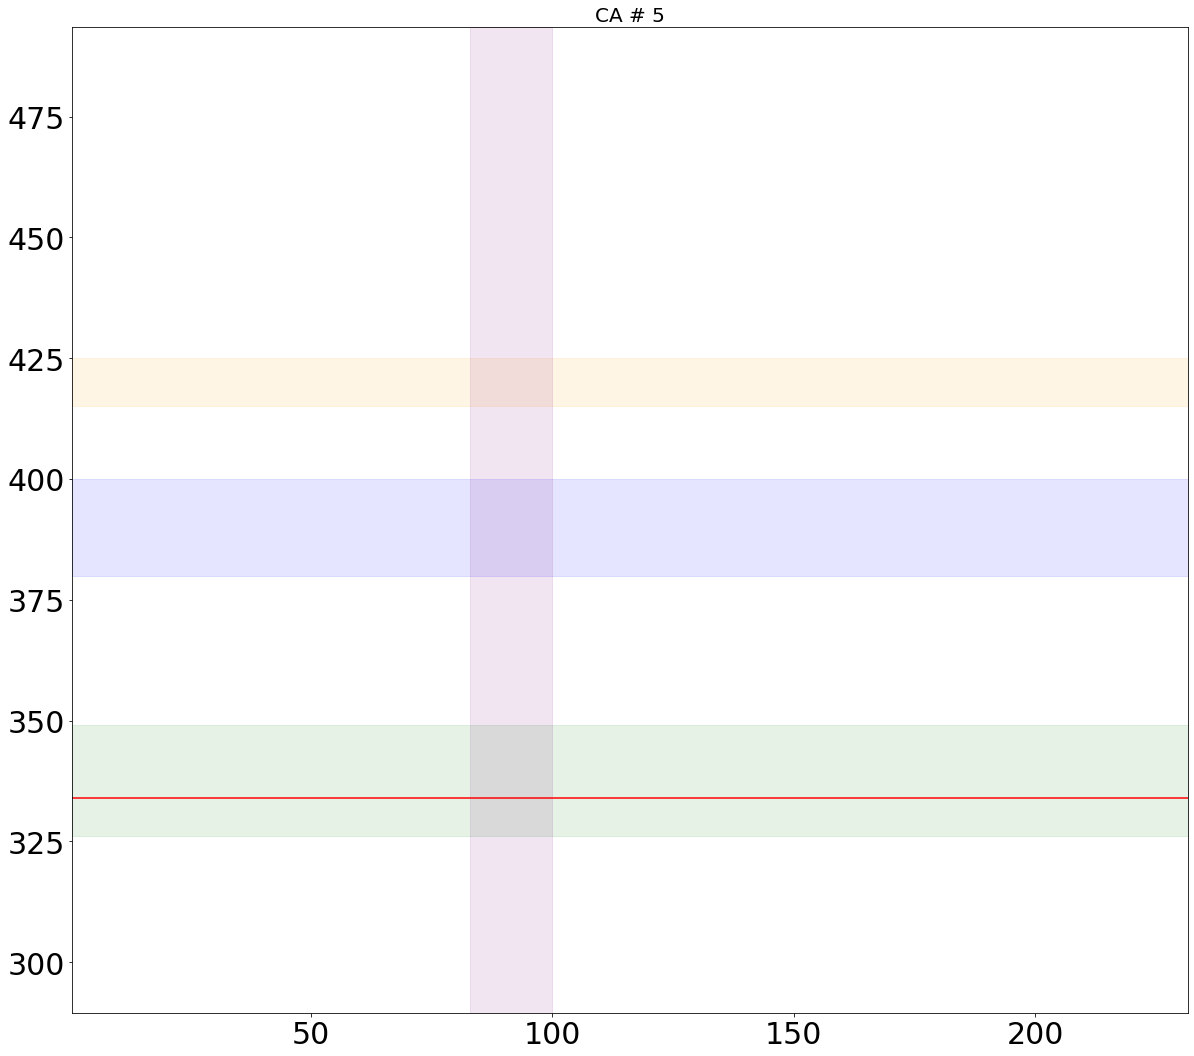

In [11]:
i=5
nspry = 494-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


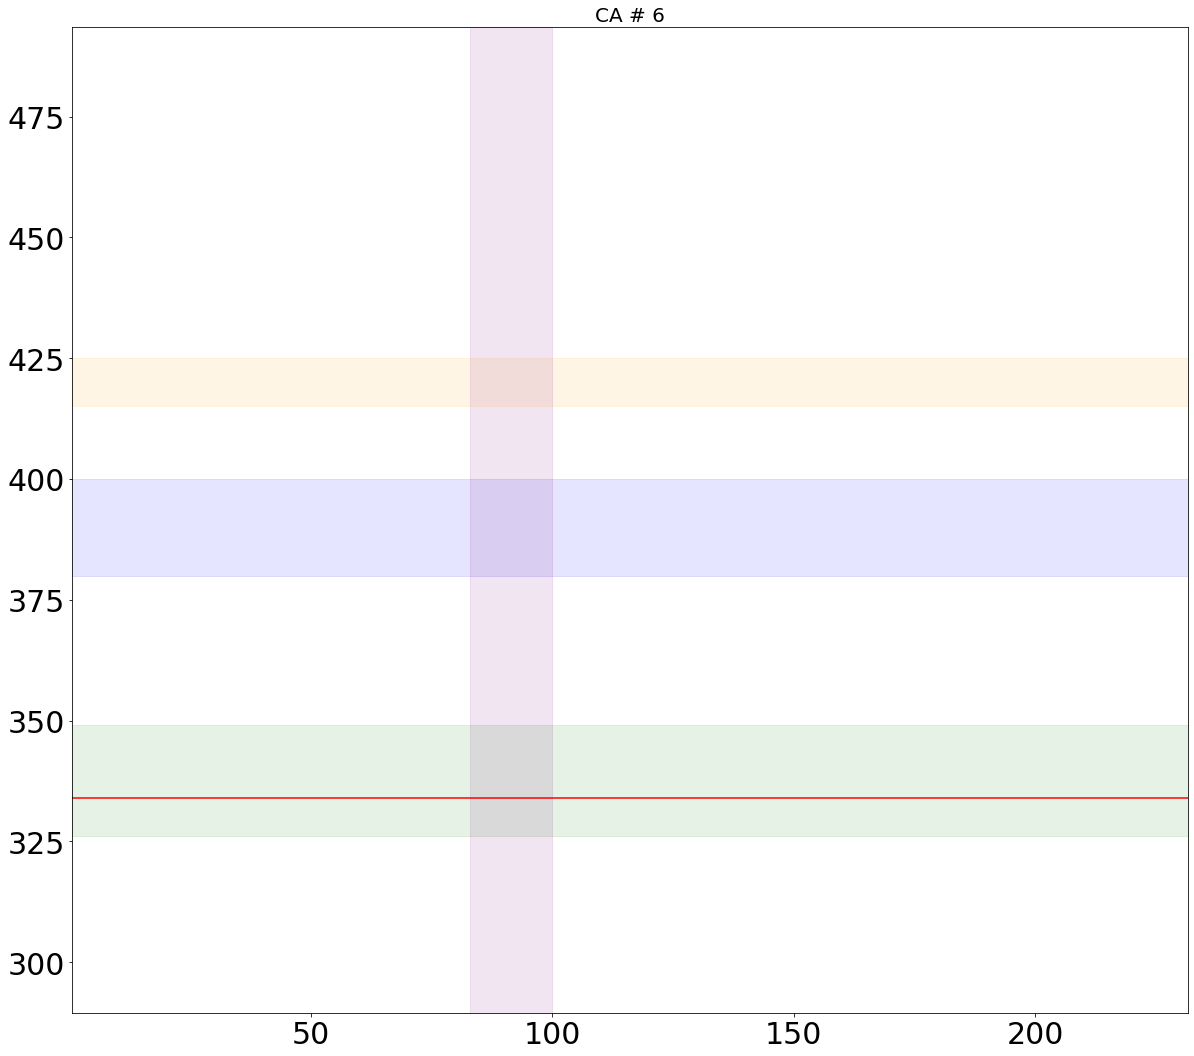

In [12]:
i=6
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


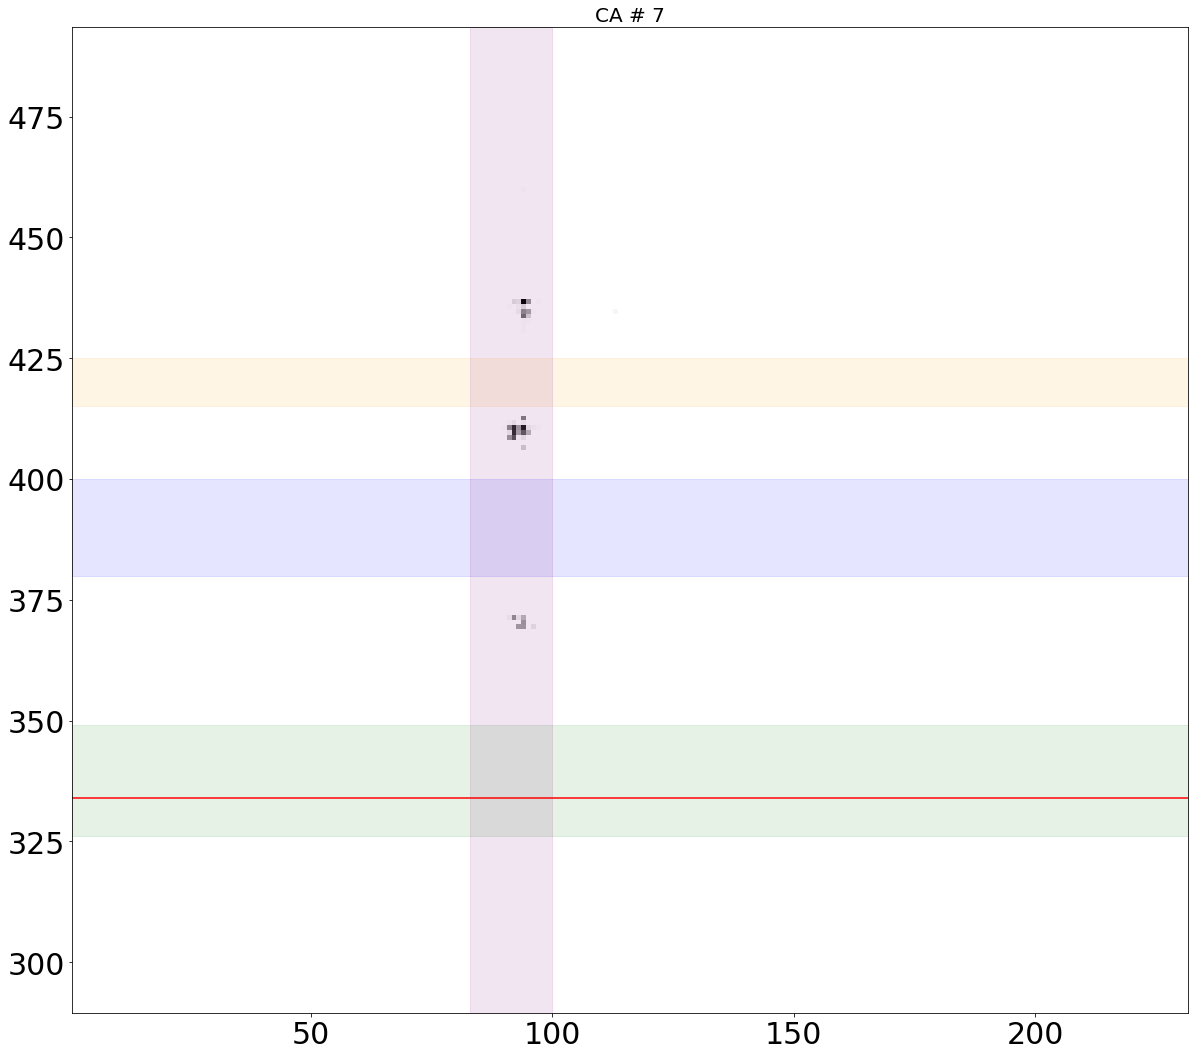

In [13]:
i=7
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


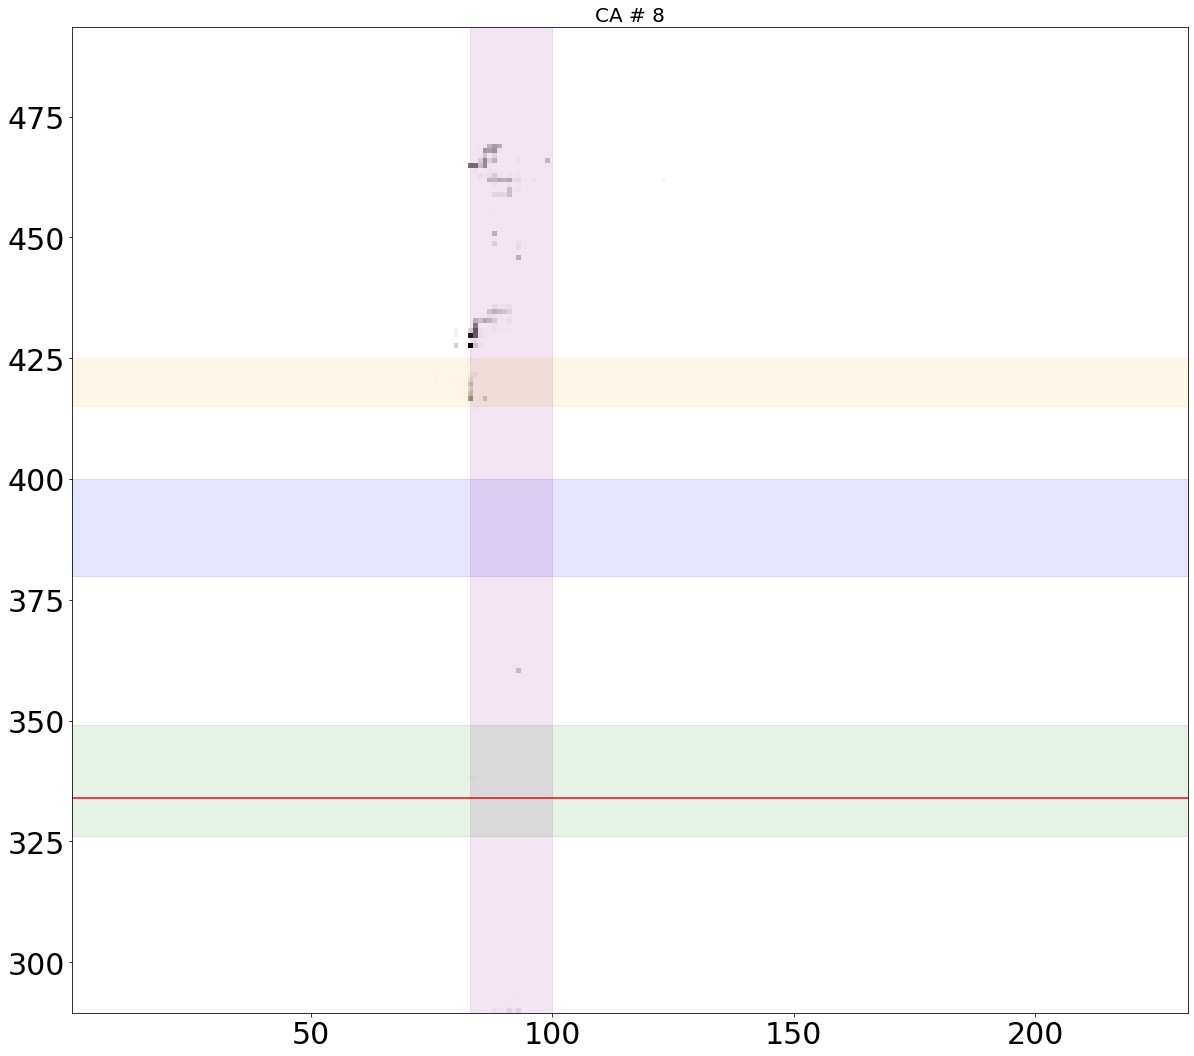

In [14]:
i=8
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


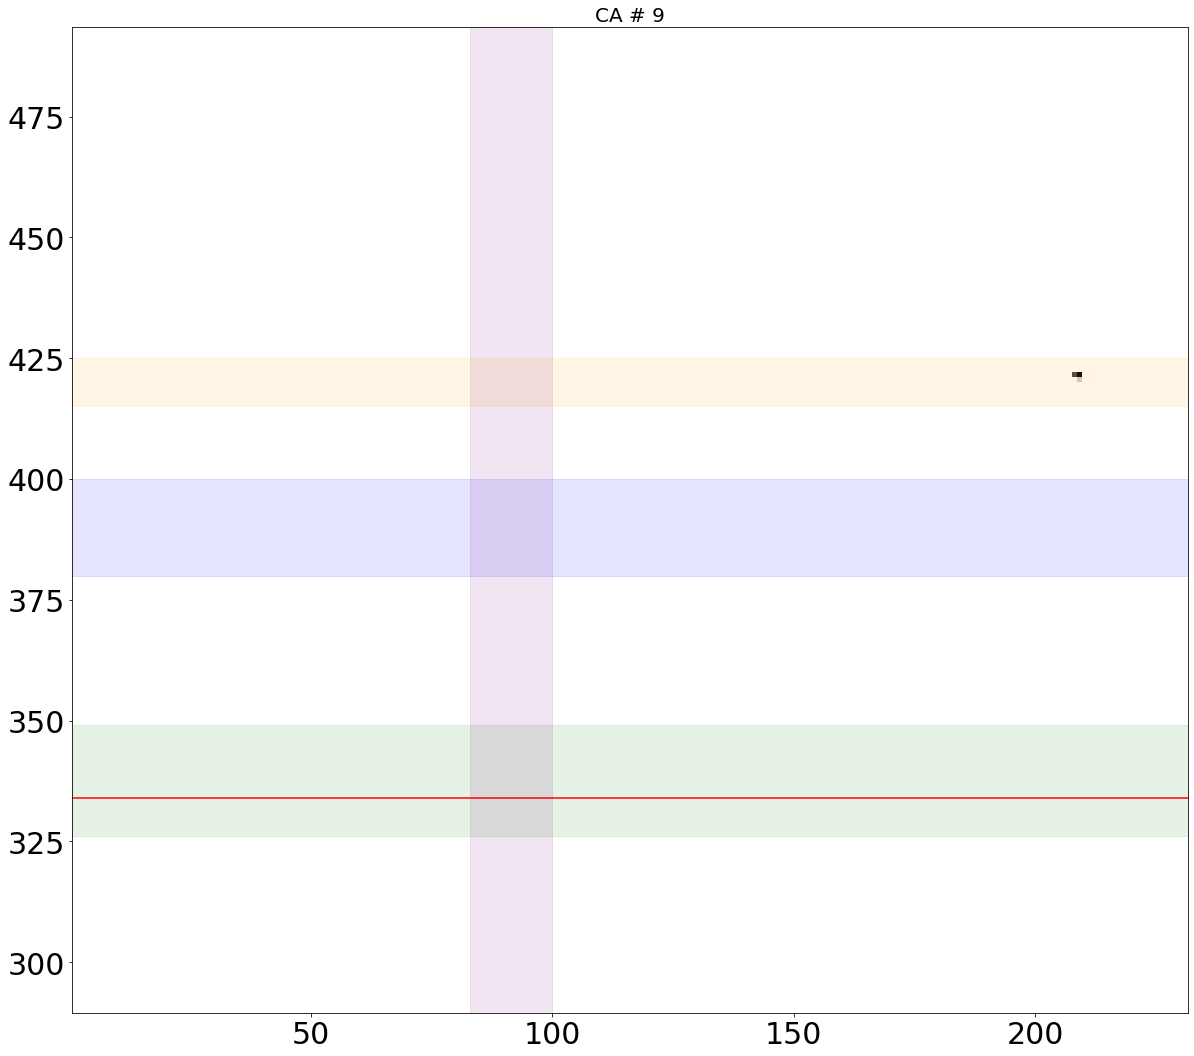

In [15]:
i=9
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


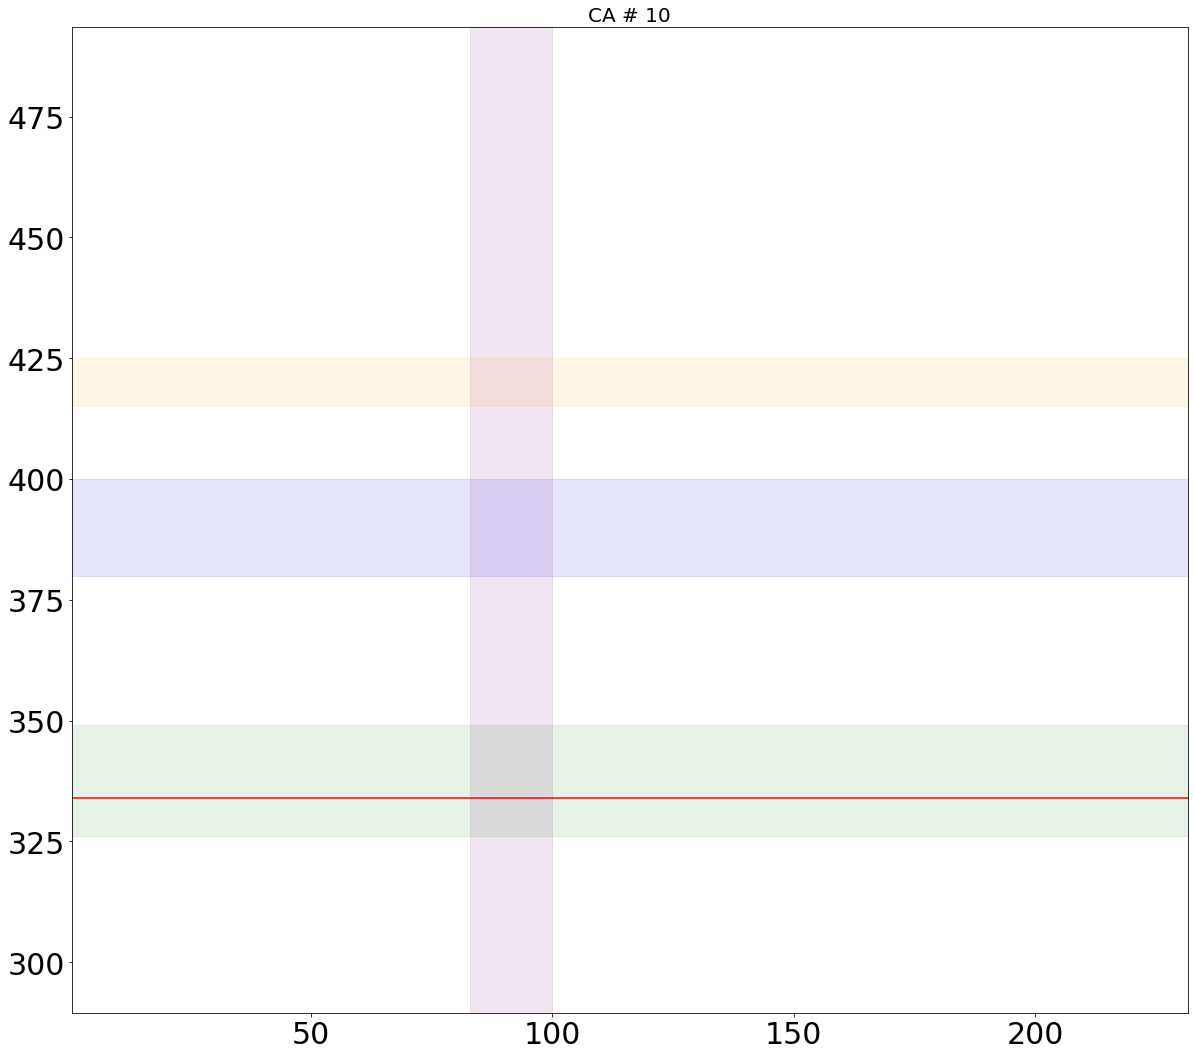

In [16]:
i=10
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


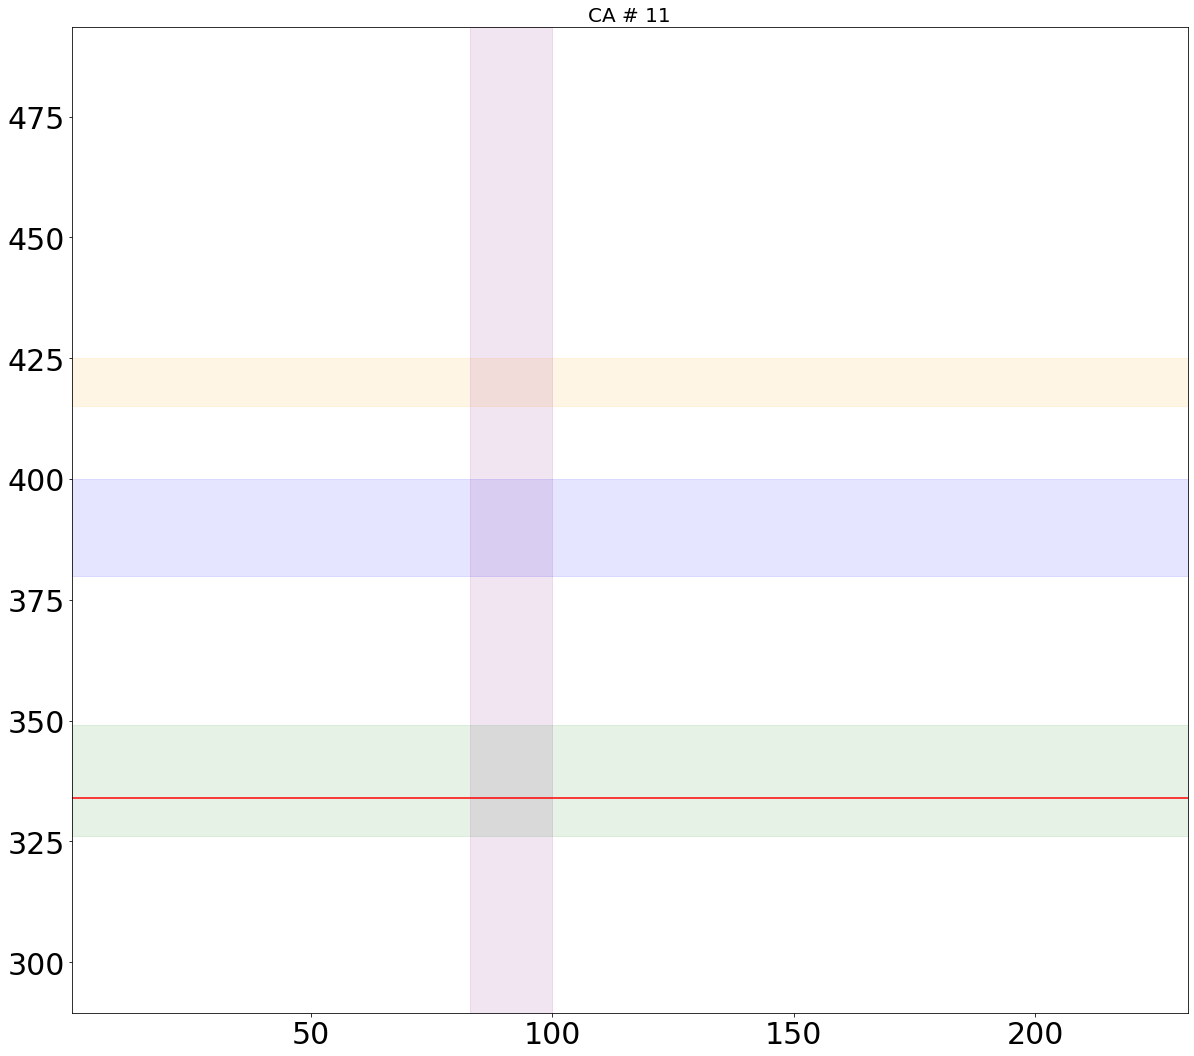

In [17]:
i=11
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


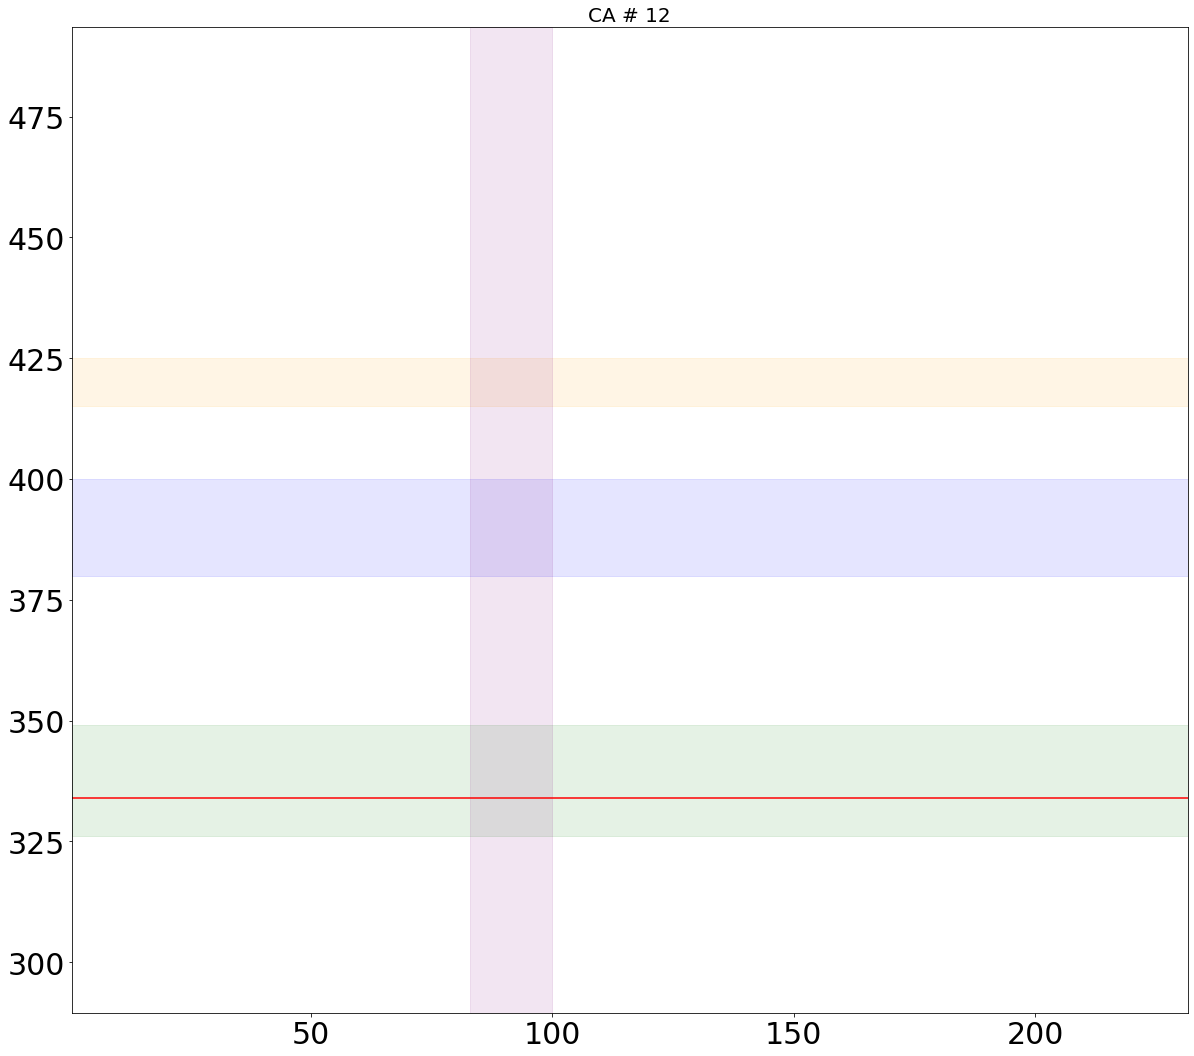

In [18]:
i=12
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


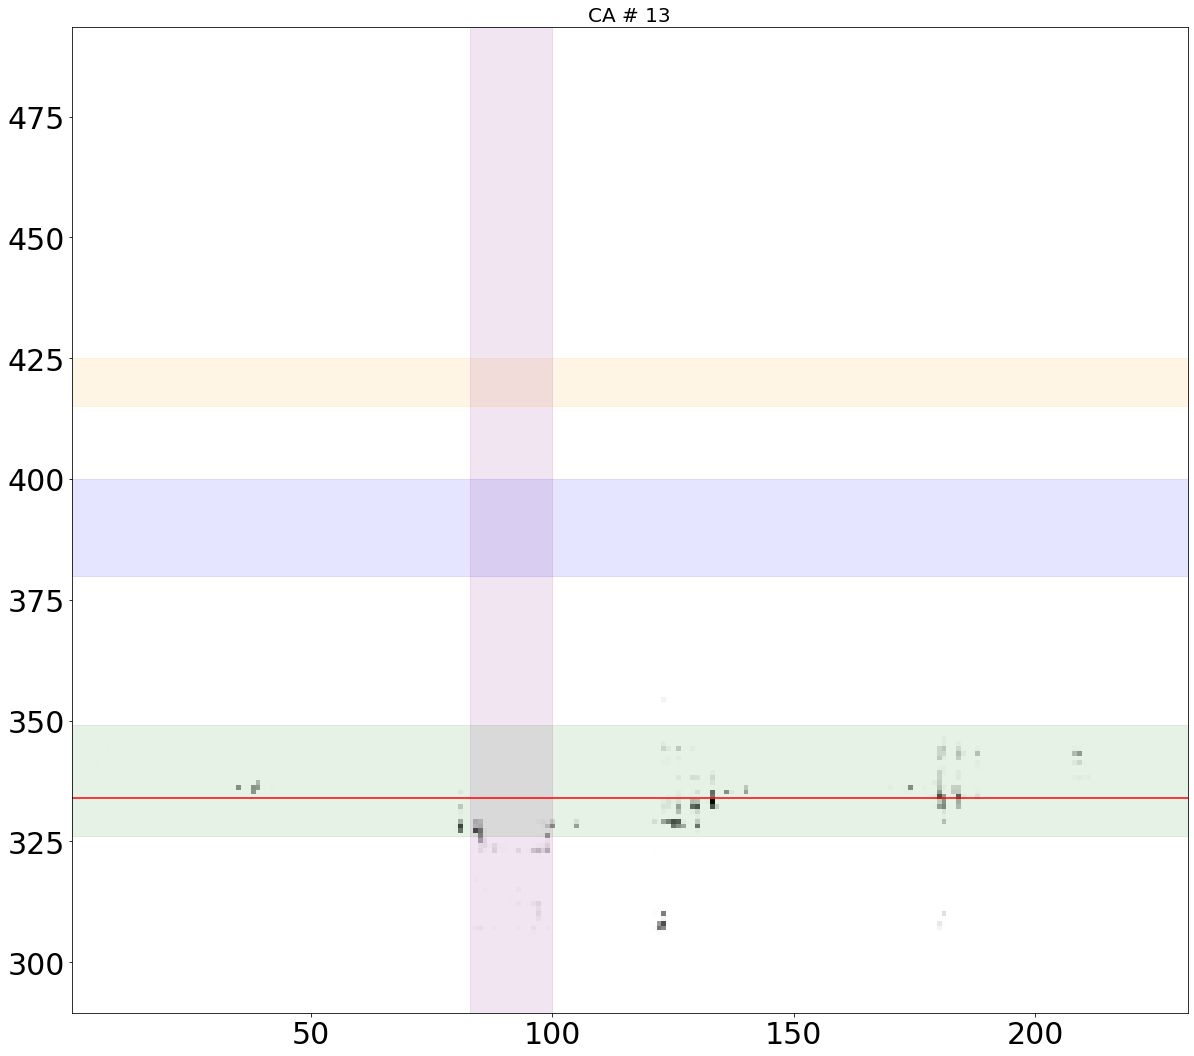

In [19]:
i=13
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


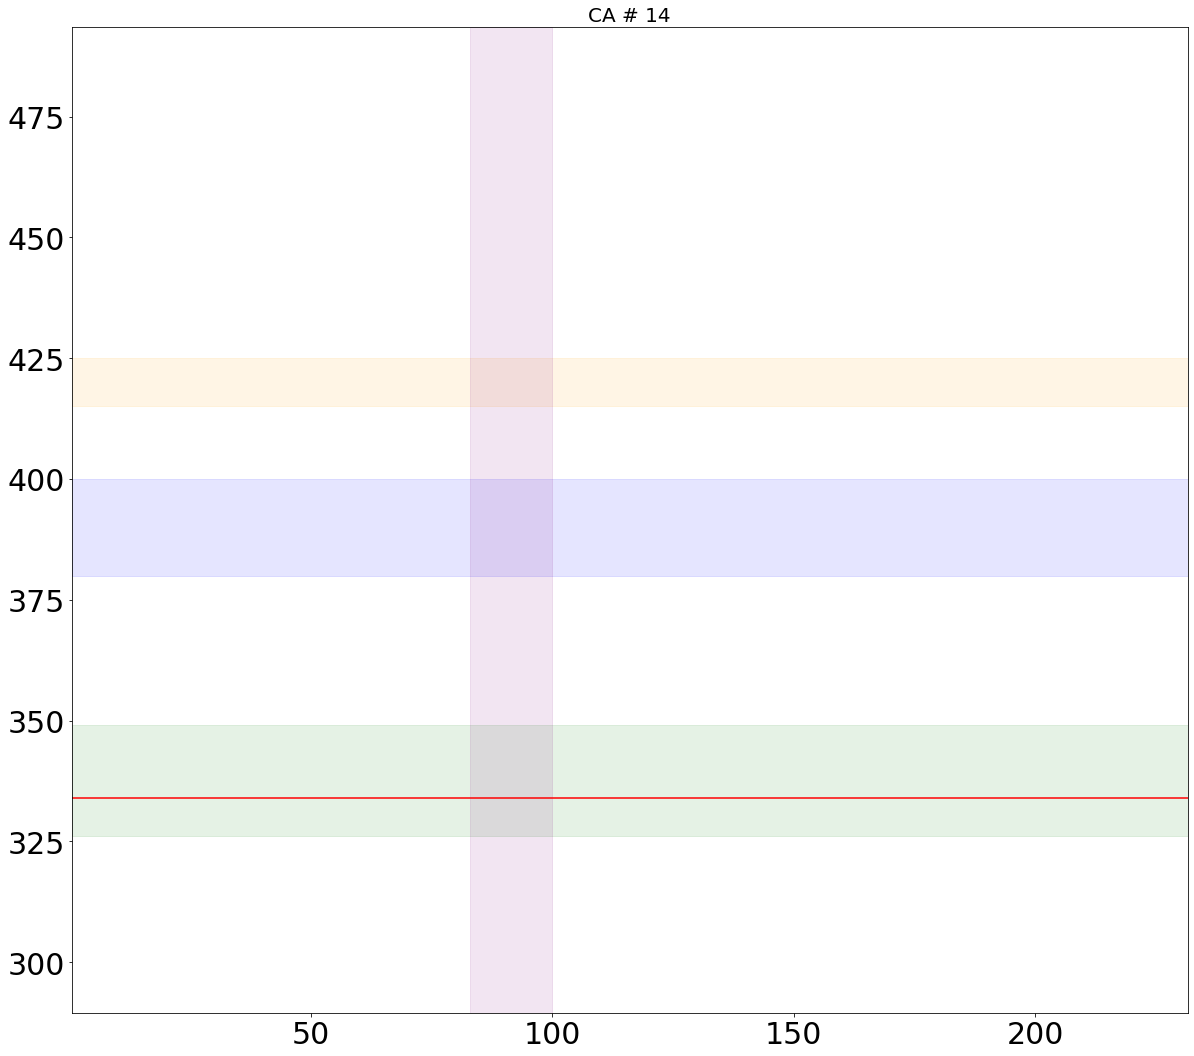

In [20]:
i=14
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


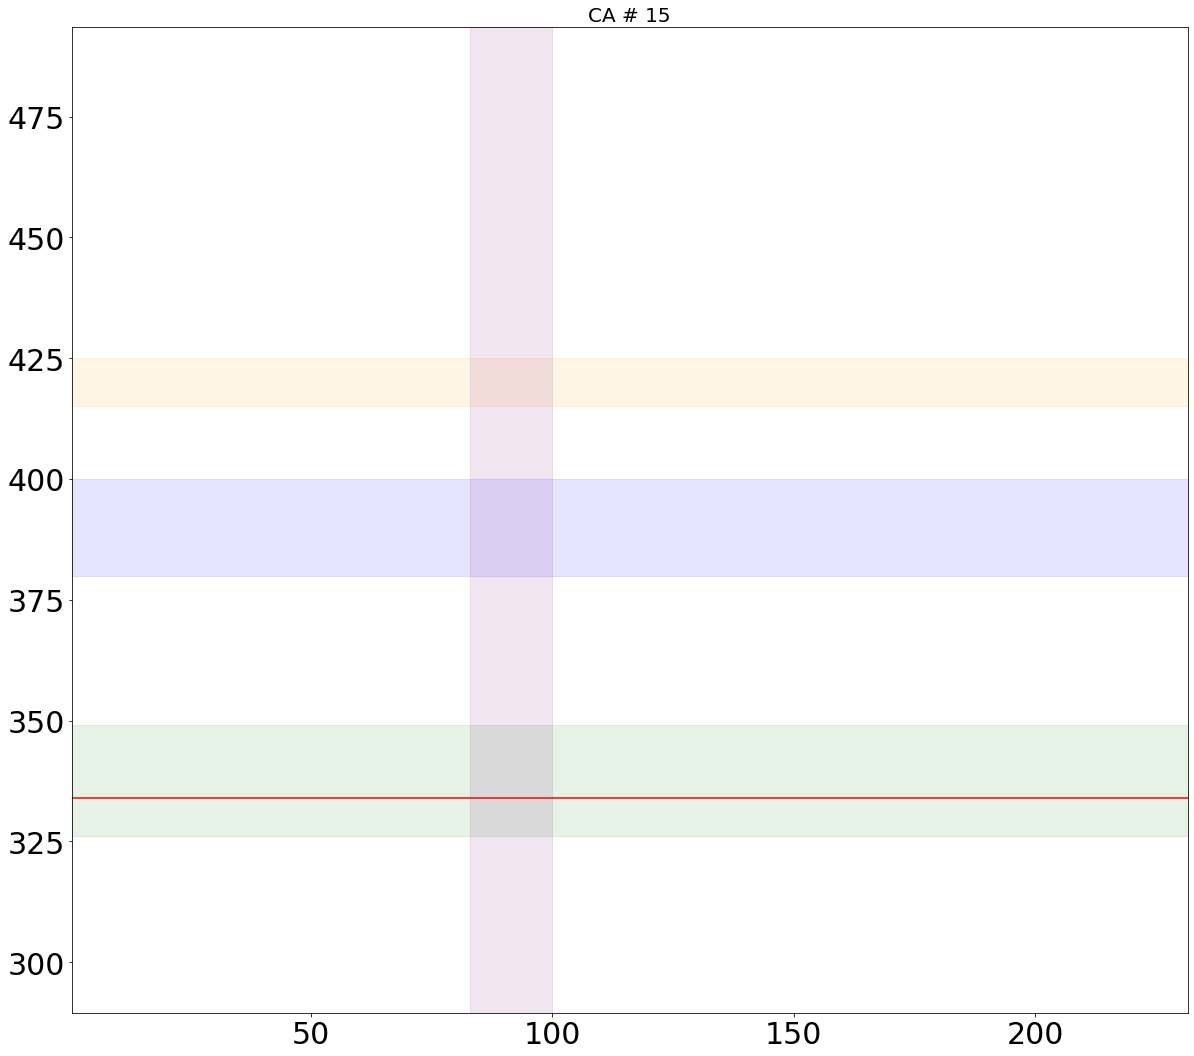

In [21]:
i=15
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


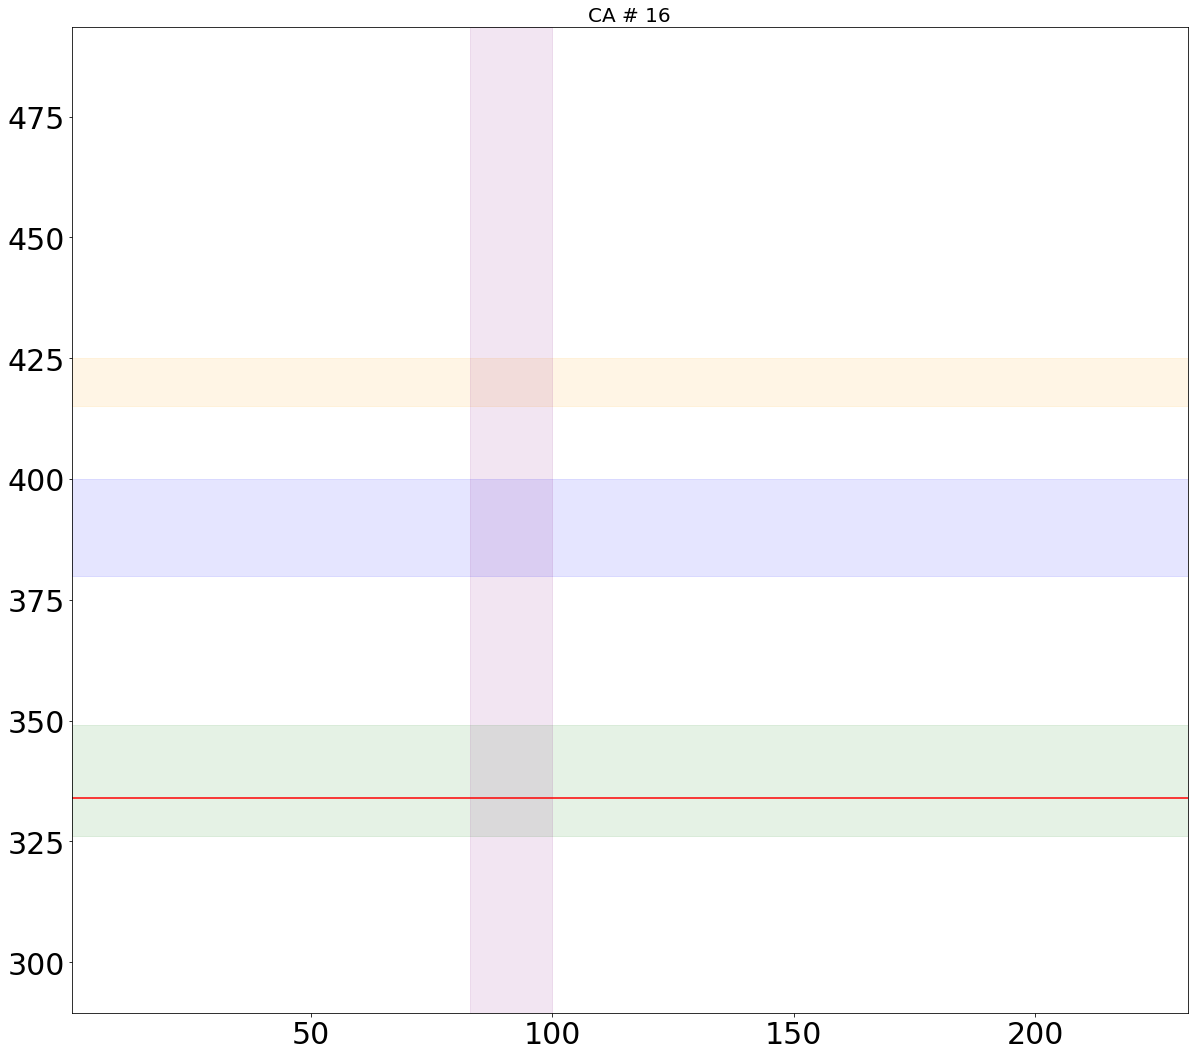

In [22]:
i=16
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


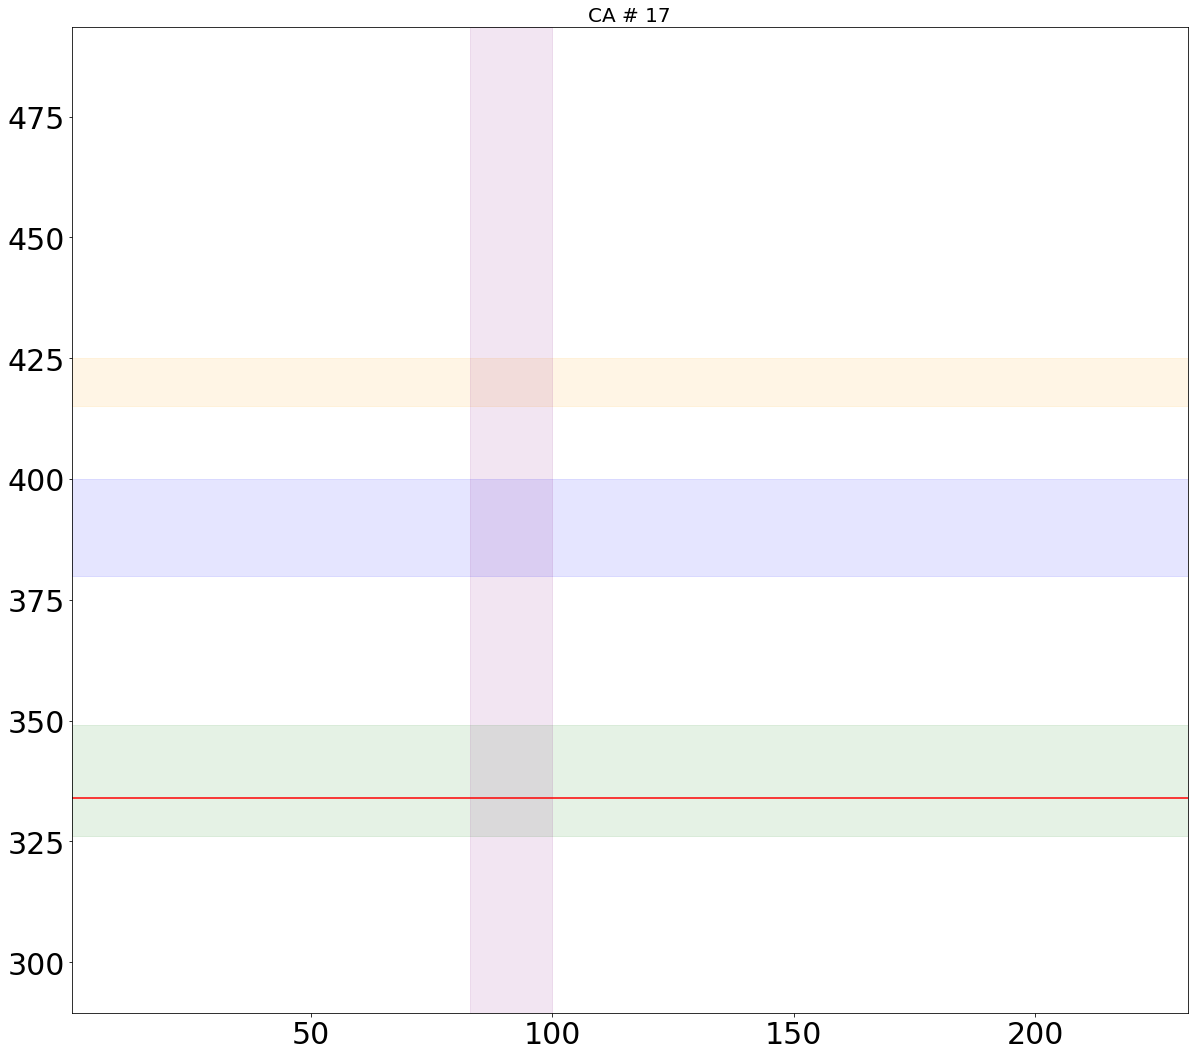

In [23]:
i=17
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")
axvspan(83,100,color = "purple",alpha = 0.1)


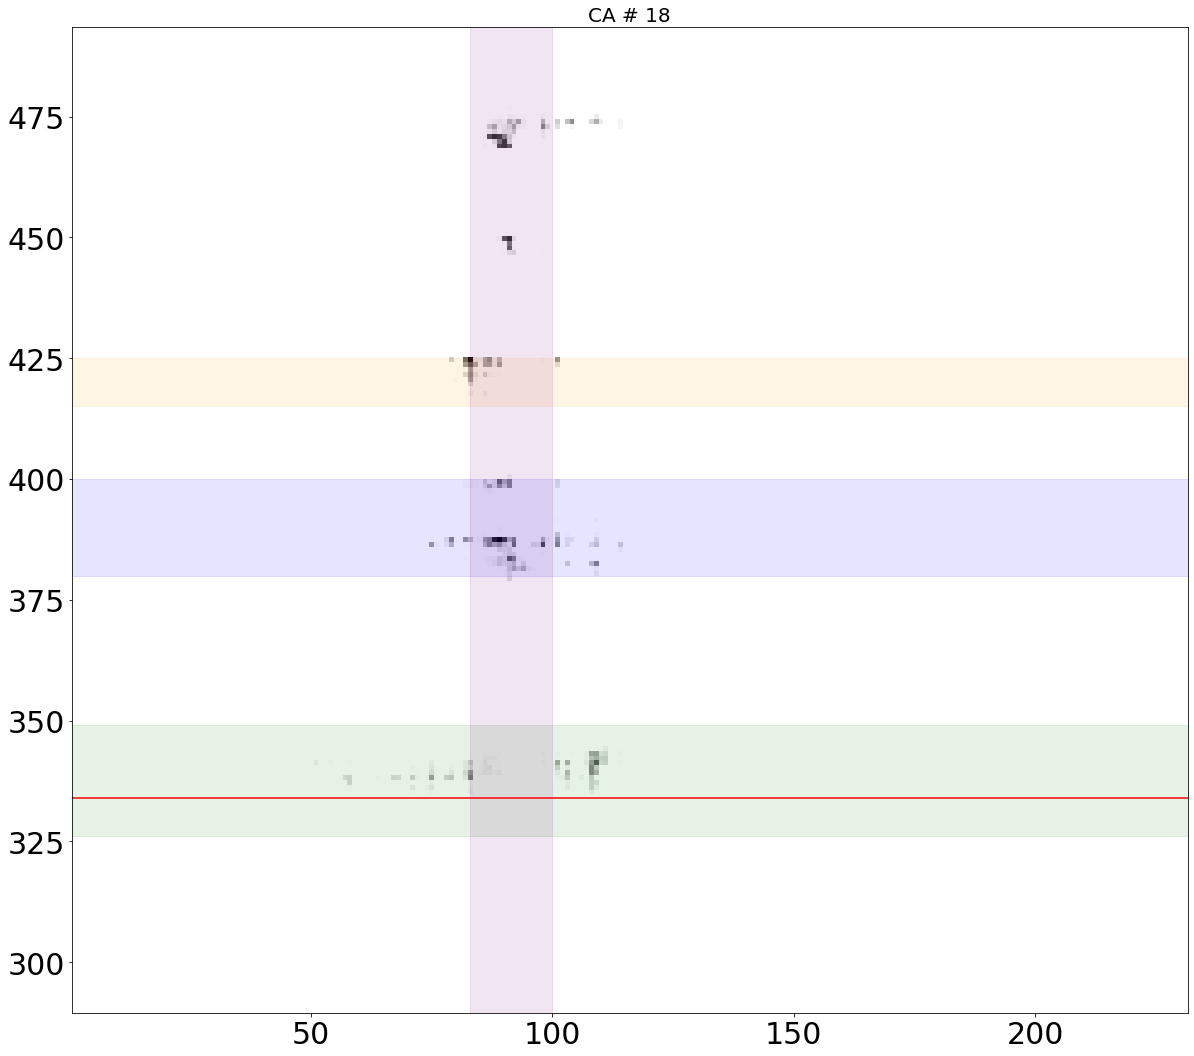

In [24]:


i=18
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)
